Loading raw tradespace data...
Evaluating metrics for 184,212 architectures... (Vectorized Python is fast!)

Computing Sensitivity and Connectivity...
 -> Analyzing metric: total_operating_cost_per_hr
 -> Analyzing metric: certification_schedule_yrs
 -> Analyzing metric: propulsion_reliability
 -> Analyzing metric: system_durability_yrs

Generating Simmon's 4-Quadrant Chart...


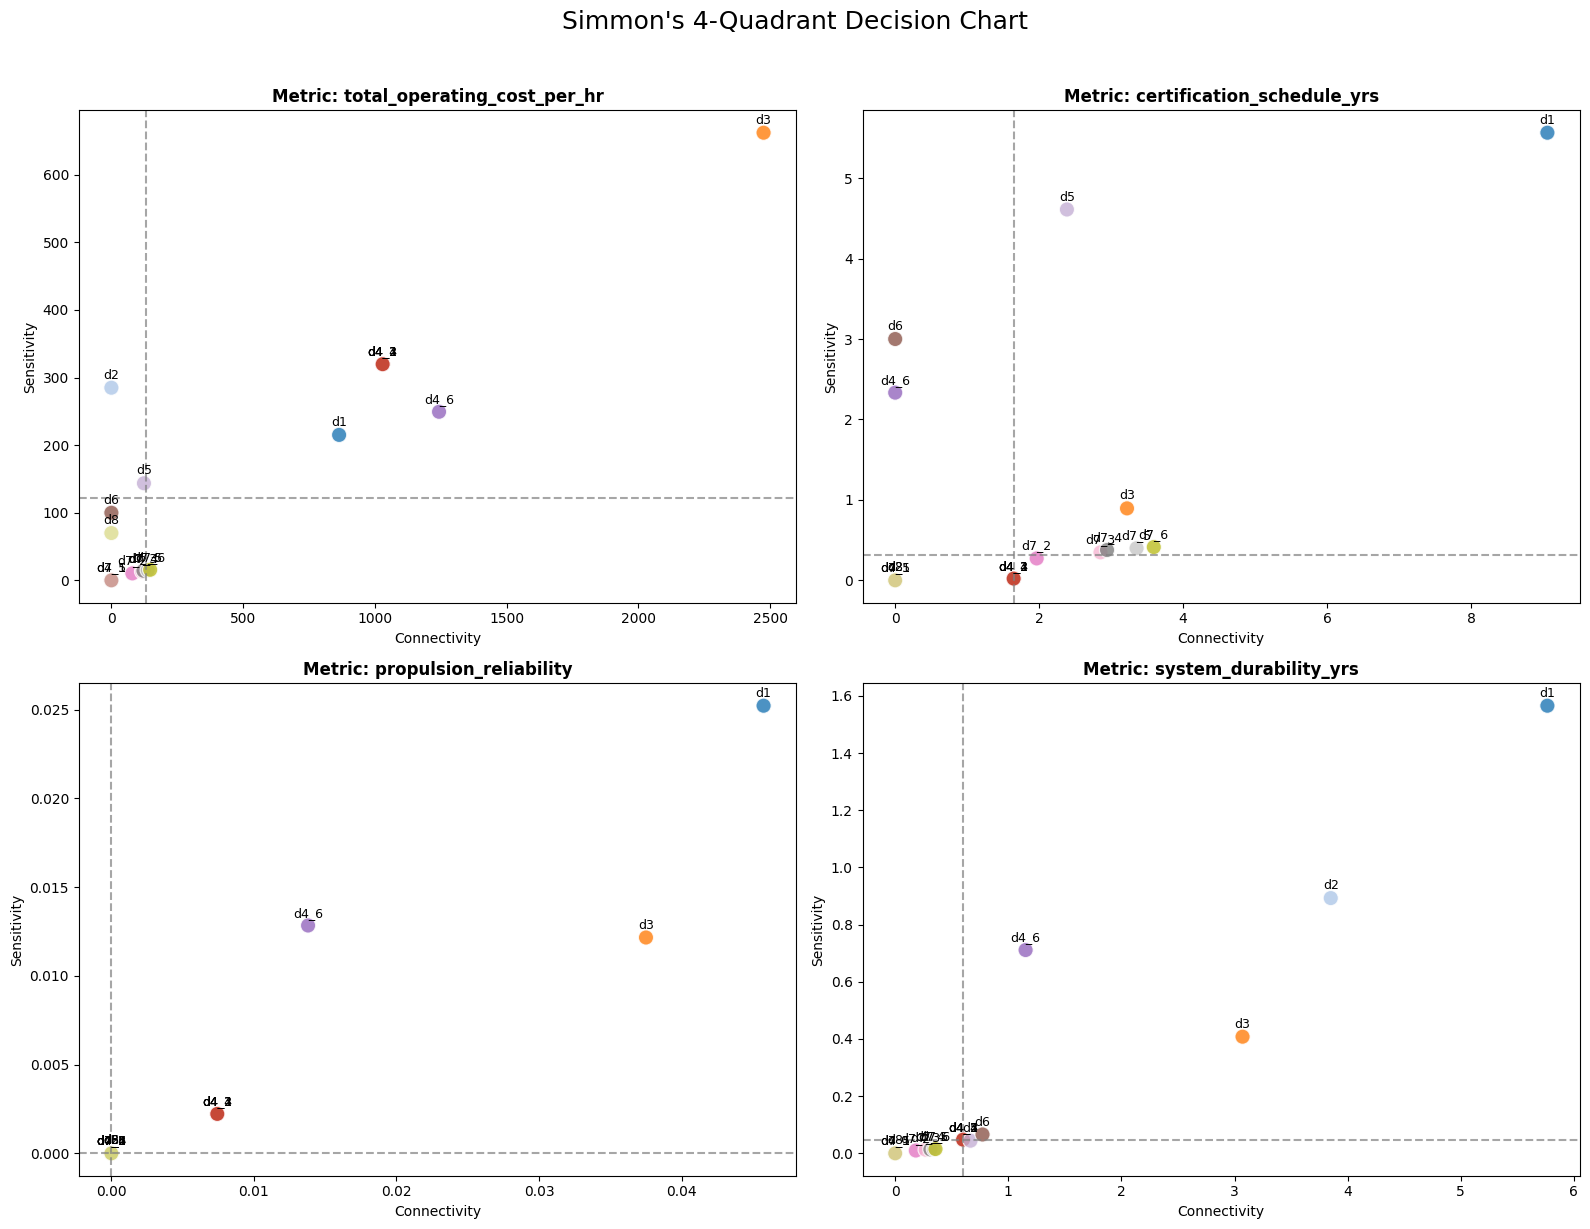


Mining Architectural Features...

--- Feature Mining Results (Exercise 3) ---
                  Feature Description  supp(F)  supp(G ∩ F)  conf(F -> G)  conf(G -> F)  lift(F ∩ G)
                 D1=0 (Series Hybrid)   0.3922       0.1154        0.2943        1.0000       2.5500
                D8=1 (CAPS Installed)   0.5000       0.0755        0.1510        0.6544       1.3087
No Nose/Tail Motors (D4_5=0 & D4_6=0)   0.6471       0.1020        0.1576        0.8837       1.3657
                  Single Motor (D3=0)   0.2745       0.0212        0.0774        0.1841       0.6705
    Simplex & Federated (D5=0 & D6=0)   0.2010       0.0315        0.1569        0.2733       1.3599
   Series Hybrid + CAPS (D1=0 & D8=1)   0.1961       0.0755        0.3851        0.6544       3.3372

Execution Complete! You can download your charts and CSVs from the left panel.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================
print("Loading raw tradespace data...")
# Make sure the file uploaded to Colab is named 'enumerated_architectures.csv'
df = pd.read_csv("/content/enumerated_architectures.csv")
pareto_data = pd.read_csv("/content/pareto_front.csv")

decision_list = ["d1", "d2", "d3", "d4_1", "d4_2", "d4_3", "d4_4", "d4_5", "d4_6",
                 "d5", "d6", "d7_1", "d7_2", "d7_3", "d7_4", "d7_5", "d7_6", "d8"]

# Force strict integer typing to prevent matching errors
for d in decision_list:
    df[d] = pd.to_numeric(df[d], errors='coerce').fillna(0).astype(int)

# ==============================================================================
# 2. EVALUATING THE TRADESPACE (Translated from Teammate's R Script)
# ==============================================================================
print("Evaluating metrics for 184,212 architectures... (Vectorized Python is fast!)")

# Helpers for arrays
d7_cols = ["d7_1", "d7_2", "d7_3", "d7_4", "d7_5", "d7_6"]
d4_wing = ["d4_1", "d4_2", "d4_3", "d4_4"]
d4_nt = ["d4_5", "d4_6"]
d4_all = d4_wing + d4_nt

# d7_val: 1 if any partition == 2 (meaning 3 partitions total), else 0
d7_val = (df[d7_cols].max(axis=1) == 2).astype(int)
# d4_any: 1 if any motor exists
d4_any = df[d4_all].max(axis=1)

# -- COST EVALUATION --
c_d1 = np.array([180, 240, 420])[df['d1']]
c_d2 = np.array([180, 170, 360])[df['d2']]
c_d3 = np.array([150, 165, 200])[df['d3']]
c_d4_wing = df[d4_wing].sum(axis=1) * 160
c_d4_nt = df[d4_nt].sum(axis=1) * 185
c_d5 = np.array([140, 175, 230])[df['d5']]
c_d6 = np.array([160, 210])[df['d6']]
c_d7 = np.array([155, 170])[d7_val]
c_d8 = np.array([195, 160])[df['d8']]
df['total_operating_cost_per_hr'] = c_d1 + c_d2 + c_d3 + c_d4_wing + c_d4_nt + c_d5 + c_d6 + c_d7 + c_d8

# -- CERTIFICATION SCHEDULE EVALUATION --
seq_time = np.array([2.0, 3.0, 6.0])[df['d1']] + np.array([1.5, 3.0, 4.5])[df['d5']] + np.array([2.0, 3.5])[df['d6']]
par_time = np.maximum.reduce([
    np.array([1.5, 1.5, 5.0])[df['d2']],
    np.array([1.5, 2.5, 4.0])[df['d3']],
    d4_any * 2.5,
    np.array([2.0, 3.0])[d7_val],
    np.array([3.5, 2.0])[df['d8']]
])
df['certification_schedule_yrs'] = np.maximum(seq_time, par_time)

# -- RELIABILITY EVALUATION --
wing_reliab = (1 - df['d4_1']*(1-0.991)) * (1 - df['d4_2']*(1-0.991)) * (1 - df['d4_3']*(1-0.991)) * (1 - df['d4_4']*(1-0.991))
nt_reliab = (1 - df['d4_5']*(1-0.994)) * (1 - df['d4_6']*(1-0.994))
R_D4 = 1 - (1 - wing_reliab) * (1 - nt_reliab)
R_series = np.array([0.996, 0.993, 0.978])[df['d1']] * np.array([0.988, 0.995, 0.993])[df['d3']] * R_D4
R_parallel = 1 - (1 - np.array([0.985, 0.995, 0.9995])[df['d5']]) * (1 - np.array([0.992, 0.991])[df['d6']]) * (1 - np.array([0.991, 0.992])[d7_val])
df['propulsion_reliability'] = R_series * R_parallel

# -- DURABILITY EVALUATION --
series_min = np.minimum.reduce([
    np.array([9.0, 8.0, 7.0])[df['d1']],
    np.array([7.5, 8.5, 9.0])[df['d2']],
    np.array([8.0, 9.0, 8.5])[df['d3']],
    d4_any * 9.5
])
parallel_max = np.maximum.reduce([
    np.array([7.0, 8.5, 10.0])[df['d5']],
    np.array([8.0, 9.0])[df['d6']],
    np.array([8.0, 8.5])[d7_val]
])
df['system_durability_yrs'] = np.minimum(series_min, parallel_max)

# Export the fully evaluated tradespace for your records
df.to_csv("evaluated_tradespace_full.csv", index=False)
metric_list = ['total_operating_cost_per_hr', 'certification_schedule_yrs', 'propulsion_reliability', 'system_durability_yrs']


# ==============================================================================
# 3. SENSITIVITY & CONNECTIVITY (EXERCISE 2 Q1/Q2)
# ==============================================================================
print("\nComputing Sensitivity and Connectivity...")

def me(dataframe, decision, value, metric):
    match_mean = dataframe.loc[dataframe[decision] == value, metric].mean()
    no_match_mean = dataframe.loc[dataframe[decision] != value, metric].mean()
    if pd.isna(match_mean) or pd.isna(no_match_mean): return 0
    return match_mean - no_match_mean

def me_ij(dataframe, dec_i, val_i, dec_j, val_j, metric):
    subset = dataframe[dataframe[dec_j] == val_j]
    if len(subset) == 0: return 0
    match_mean = subset.loc[subset[dec_i] == val_i, metric].mean()
    no_match_mean = subset.loc[subset[dec_i] != val_i, metric].mean()
    if pd.isna(match_mean) or pd.isna(no_match_mean): return 0
    return match_mean - no_match_mean

def calc_sensitivity(dataframe, decision, metric):
    vals = dataframe[decision].dropna().unique()
    effects = [me(dataframe, decision, v, metric) for v in vals]
    return np.max(effects) - np.min(effects) if len(effects) > 1 else 0

def calc_connectivity(dataframe, decision_i, decisions, metric):
    conn = 0
    vals_i = dataframe[decision_i].dropna().unique()
    for d_j in decisions:
        if decision_i == d_j: continue
        vals_j = dataframe[d_j].dropna().unique()
        for v_i in vals_i:
            effects = [me_ij(dataframe, decision_i, v_i, d_j, v_j, metric) for v_j in vals_j]
            if len(effects) > 1:
                conn += (np.max(effects) - np.min(effects))
    return conn

results = []
for m in metric_list:
    print(f" -> Analyzing metric: {m}")
    for d in decision_list:
        s = calc_sensitivity(df, d, m)
        c = calc_connectivity(df, d, decision_list, m)
        results.append({'Metric': m, 'Decision': d, 'Connectivity': c, 'Sensitivity': s})

df_points = pd.DataFrame(results)
df_points.to_csv("Ex2_1_Sensitivity_Connectivity_Table.csv", index=False)


# ==============================================================================
# 4. SIMMON'S 4-QUADRANT CHART (EXERCISE 2 Q2)
# ==============================================================================
print("\nGenerating Simmon's 4-Quadrant Chart...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, m in enumerate(metric_list):
    ax = axes[i]
    subset = df_points[df_points['Metric'] == m]
    med_c = subset['Connectivity'].median()
    med_s = subset['Sensitivity'].median()

    sns.scatterplot(data=subset, x='Connectivity', y='Sensitivity', hue='Decision',
                    s=120, alpha=0.8, ax=ax, legend=False, palette='tab20')

    for _, row in subset.iterrows():
        ax.text(row['Connectivity'], row['Sensitivity'] + (subset['Sensitivity'].max()*0.02),
                row['Decision'], fontsize=9, ha='center')

    ax.axvline(med_c, color='gray', linestyle='--', alpha=0.7)
    ax.axhline(med_s, color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f"Metric: {m}", fontweight='bold')
    ax.set_xlabel("Connectivity")
    ax.set_ylabel("Sensitivity")

plt.suptitle("Simmon's 4-Quadrant Decision Chart", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("Ex2_2_Simmons_4_Quadrant_Chart.png", dpi=300, bbox_inches='tight')
plt.show()


# ==============================================================================
# 5. FEATURE MINING (EXERCISE 2 Q3)
# ==============================================================================
print("\nMining Architectural Features...")

# Match architectures in full dataset to the Pareto front
df['encoding_str'] = df[decision_list].astype(str).agg('_'.join, axis=1)
pareto_data['encoding_str'] = pareto_data[decision_list].astype(str).agg('_'.join, axis=1)
valid_encodings = set(pareto_data['encoding_str'])
df['in_G'] = df['encoding_str'].isin(valid_encodings)

def get_metrics(dataframe, feature_desc, condition_mask):
    N_total = len(dataframe)
    N_G = dataframe['in_G'].sum()

    df_F = dataframe[condition_mask]
    N_F = len(df_F)
    N_G_and_F = df_F['in_G'].sum()

    supp_F = N_F / N_total if N_total else 0
    supp_G_and_F = N_G_and_F / N_total if N_total else 0
    conf_F_to_G = N_G_and_F / N_F if N_F > 0 else 0
    conf_G_to_F = N_G_and_F / N_G if N_G > 0 else 0
    supp_G = N_G / N_total if N_total else 0
    lift = conf_F_to_G / supp_G if supp_G > 0 else 0

    return {
        'Feature Description': feature_desc,
        'supp(F)': round(supp_F, 4),
        'supp(G ∩ F)': round(supp_G_and_F, 4),
        'conf(F -> G)': round(conf_F_to_G, 4),
        'conf(G -> F)': round(conf_G_to_F, 4),
        'lift(F ∩ G)': round(lift, 4)
    }

features = [
    get_metrics(df, "D1=0 (Series Hybrid)", df['d1'] == 0),
    get_metrics(df, "D8=1 (CAPS Installed)", df['d8'] == 1),
    get_metrics(df, "No Nose/Tail Motors (D4_5=0 & D4_6=0)", (df['d4_5'] == 0) & (df['d4_6'] == 0)),
    get_metrics(df, "Single Motor (D3=0)", df['d3'] == 0),
    get_metrics(df, "Simplex & Federated (D5=0 & D6=0)", (df['d5'] == 0) & (df['d6'] == 0)),
    get_metrics(df, "Series Hybrid + CAPS (D1=0 & D8=1)", (df['d1'] == 0) & (df['d8'] == 1))
]

df_features = pd.DataFrame(features)
df_features.to_csv("Ex2_3_Feature_Mining_Table.csv", index=False)

print("\n--- Feature Mining Results (Exercise 3) ---")
print(df_features.to_string(index=False))
print("\nExecution Complete! You can download your charts and CSVs from the left panel.")